# Loading Data

In [69]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [72]:
from tweezepy import allanvar

In [2]:
def process_data(data_txt):
    # Read data
    cols = ['MJD','R.A. (mas)', 'Dec. (mas)', 'Err. R.A. (mas)', 'Err. Dec. (mas)', 'Corr.', 'Del.']
    cols_widths = [(0,9),(9,26),(27,46),(47,56),(57,66),(67,74),(75,79)]
    df = pd.read_fwf(data_txt, colspecs=cols_widths, skiprows=4, header=None, names=cols) 
    
    # Convert to float
    df_new = df.apply(pd.to_numeric, errors='coerce').dropna()    
    
    # Convert from mas to microas
    df_new['R.A. (micas)'] = df_new['R.A. (mas)']*1000
    df_new['Dec. (micas)'] = df_new['Dec. (mas)']*1000
    df_new['Err. R.A. (micas)'] = df_new['Err. R.A. (mas)']*1000
    df_new['Err. Dec. (micas)'] = df_new['Err. Dec. (mas)']*1000
    
    # Convert from mas to degrees to radian
    df_new['Dec. (rad)'] = (df_new['Dec. (micas)']/(3600*1000)).apply(np.deg2rad)
    
    # Calculate RA*cos(dec) column
    
    df_new['RAcosDEC'] = df_new['R.A. (micas)']*np.cos(df_new['Dec. (rad)'])
    
    # Calculate Besselian Year column
    df_new['BY'] = 2000-(51544.333981-df_new['MJD'])/365.242198781
    
    return df_new

In [3]:
df = process_data('ICRF3 Dem/series_ind_dem/1803+784_dem.txt')
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,R.A. (micas),Dec. (micas),Err. R.A. (micas),Err. Dec. (micas),Dec. (rad),RAcosDEC,BY
0,45754.258,-1.910705,-1.887599,1.2912,0.7417,-0.084,40,-1910.704737,-1887.598813,1291.2,741.7,-0.000009,-1910.704737,1984.147297
1,45759.251,-1.555439,-2.306200,1.2032,1.1362,0.028,19,-1555.438834,-2306.199571,1203.2,1136.2,-0.000011,-1555.438834,1984.160968
2,45764.244,0.049960,1.459800,0.7069,0.6182,0.325,21,49.959984,1459.800012,706.9,618.2,0.000007,49.959984,1984.174638
3,45769.259,-5.739611,0.890402,2.5316,1.1073,-0.363,25,-5739.611378,890.402401,2531.6,1107.3,0.000004,-5739.611378,1984.188369
4,45864.264,-2.973084,0.696002,0.6484,0.6307,0.547,27,-2973.083789,696.002411,648.4,630.7,0.000003,-2973.083789,1984.448484


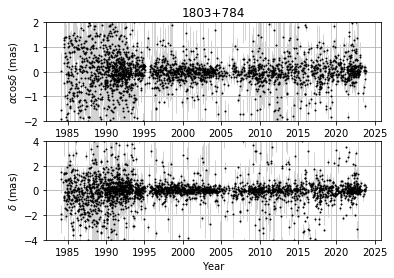

In [4]:
plt.subplot(211)
plt.title('1803+784')
plt.errorbar(df['BY'], df['RAcosDEC']/1000,yerr=df['Err. R.A. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-2,2)
plt.xlabel('Year')
plt.ylabel(r'$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df['BY'], df['Dec. (mas)'], yerr=df['Err. Dec. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-4,4)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

# Old Way

In [ ]:
def allanoadev(y,dates,error):
        
    # === Parameters ===
    
    # Length of observation
    N = len(y)
        
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # Take tau0 as 1/rate
    tau0 =  np.mean(np.diff(dates))
    # steps
    step = 1
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []
    
    # Create weights 
    weights_std = []
    for val in error:
        if val != 0:
            weights_std.append(1/(val**2))
        elif val == 0:
            weights_std.append(0)

    # Iterate over values of m
    for k in range(len(m)): 
        # Sliding windows 
        left = 0 
        right = m[k]
        ybar = []
        D = 0
        data_sum = 0
        
        # Check for missing windows 
        while right <= N:
            data_values = y[left:right]
            data_sum = np.sum(data_values)
    
            if data_sum == 0:
                D +=1
            else:
                avg = np.average(data_values, weights=weights_std[left:right])
                ybar.append(avg)
            left += step 
            right += step    
            

        M_D = len(ybar)

        # Calculate allan var 
        outersum = []
        j = 0
        while j < M_D-2*m[k]+1:
            i = j
            ysum = []
            while i <= j+m[k]-1:
                ysum.append(ybar[i+m[k]]-ybar[i])
                i += 1
            outersum.append(0.5*(np.sum(ysum)/m[k])**2)
            j += 1


        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M_D-2*m[k]+1))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [ ]:
%%time
tau_dec, allanstd_dec = allanoadev(df['Dec. (micas)'].values,df['MJD'],df['Err. Dec. (micas)'])

In [ ]:
tau_year_dec = [x/365.242198781 for x in tau_dec]

In [ ]:
plt.plot(tau_year_dec,allanstd_dec)
plt.yscale('log')
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel('Allan std dev in $\delta$ [microas?]')

# New Way

In [38]:
def allanoadev_new(y,t,error):
        
    # === Parameters ===
    
    # Length of observation
    N = len(y)
        
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # initial sampling time
    tau0 =  np.mean(np.diff(t))
    # steps
    step = tau0
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []

    # Iterate over values of m
    for k in range(len(m)): 
        # Sliding windows 
        left = min(t)
        right = min(t) + m[k]*tau0

        # Array for averages
        ybar = []

        # Array for amount of data points
        Nrray = []

        # Define no of windows with <= 2 data points
        nconstraint = 2
                
        # Check for missing windows 
        while right <= max(t):
            data_values = y[(t>=left) & (t<=right)]
            Ndata = len(data_values)
            Nrray.append(Ndata)

            if Ndata == 0:
                ybar.append(np.nan)
            else:
                if error is None: 
                    avg = np.average(data_values)
                    ybar.append(avg)
                else:
                    weights_std = 1/error[(t>=left) & (t<=right)]**2
                    avg = np.average(data_values, weights=weights_std)
                    ybar.append(avg)
            left += step 
            right += step    

        # Define empty windows 
        Nrray = np.array(Nrray)
        ybar = np.array(ybar)
        
        D = len(ybar[Nrray<=nconstraint])
        M = len(ybar)
        print(k,len(m),M,D)

        # Discard windows with too few data points
        ybar = ybar[Nrray>nconstraint]

        # Calculate allan var 
        outersum = []
        j = 0
        while j < M-2*m[k]+1-D:
            i = j
            innersum = []
            while i <= j+m[k]-1:
                innersum.append(ybar[i+m[k]]-ybar[i])
                i += 1
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)
            j += 1


        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1-D))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


In [39]:
%%time
tau_dec_new, allanstd_dec_new = allanoadev_new(df['Dec. (micas)'].values,df['MJD'].values,df['Err. Dec. (micas)'].values)

0 908 2729 1160
1 908 2728 686
2 908 2727 499
3 908 2726 361
4 908 2725 266
5 908 2724 203
6 908 2723 159
7 908 2722 130
8 908 2721 112
9 908 2720 92
10 908 2719 78
11 908 2718 64
12 908 2717 52
13 908 2716 40
14 908 2715 31
15 908 2714 21
16 908 2713 14
17 908 2712 9
18 908 2711 4
19 908 2710 2
20 908 2709 1
21 908 2708 0
22 908 2707 0
23 908 2706 0
24 908 2705 0
25 908 2704 0
26 908 2703 0
27 908 2702 0
28 908 2701 0
29 908 2700 0
30 908 2699 0
31 908 2698 0
32 908 2697 0
33 908 2696 0
34 908 2695 0
35 908 2694 0
36 908 2693 0
37 908 2692 0
38 908 2691 0
39 908 2690 0
40 908 2689 0
41 908 2688 0
42 908 2687 0
43 908 2686 0
44 908 2685 0
45 908 2684 0
46 908 2683 0
47 908 2682 0
48 908 2681 0
49 908 2680 0
50 908 2679 0
51 908 2678 0
52 908 2677 0
53 908 2676 0
54 908 2675 0
55 908 2674 0
56 908 2673 0
57 908 2672 0
58 908 2671 0
59 908 2670 0
60 908 2669 0
61 908 2668 0
62 908 2667 0
63 908 2666 0
64 908 2665 0
65 908 2664 0
66 908 2663 0
67 908 2662 0
68 908 2661 0
69 908 2660 0
70 

In [47]:
allanstd_dec_new

array([416.7239926 , 384.8364589 , 379.3592322 , 361.17870946,
       366.09888252, 388.05018095, 430.52584772, 477.84066361,
       512.81766376, 544.67890764, 579.5960232 , 584.96281123,
       589.88442373, 680.06921083, 766.19650034, 877.89742362,
       974.0353991 , 942.82380489, 912.20661124, 885.67216665,
       859.69741631, 838.86725382, 818.89643674, 779.28094535,
       749.17564668, 709.07625054, 673.46103872, 651.35890668,
       627.01902578, 611.64530286, 597.06995291, 584.43206218,
       571.78487974, 559.07089379, 546.53972053, 532.39468338,
       522.02748485, 509.94488851, 500.0632803 , 490.04212934,
       480.20190652, 470.15515471, 459.94216199, 450.16763453,
       441.20590063, 433.05599216, 425.02632622, 416.76936437,
       408.08802304, 399.32549229, 391.2084861 , 383.03655133,
       375.6897262 , 368.44204975, 361.39308224, 354.26869847,
       347.70238732, 341.07964539, 334.89796326, 328.76698507,
       322.9100271 , 317.61977432, 312.18943285, 306.81

In [48]:
len(allanstd_dec_new)

908

In [40]:
tau_dec_year = [x/365.242198781 for x in tau_dec_new]

Text(0, 0.5, 'Allan std dev in $\\delta$ [mas]')

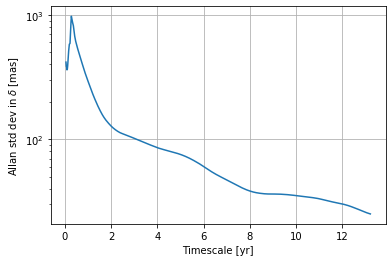

In [50]:
plt.plot(tau_dec_year,allanstd_dec_new)
plt.yscale('log')
plt.grid()
plt.xlabel('Timescale [yr]')
plt.ylabel('Allan std dev in $\delta$ [mas]')

In [43]:
fs = 12
color = 'black'
ymin = 1
ymax = 10000

No handles with labels found to put in legend.


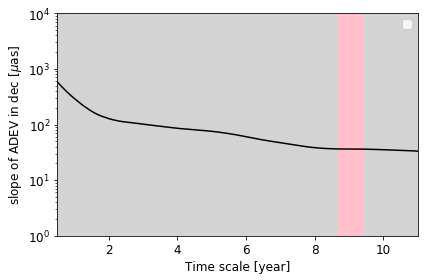

In [55]:
plt.figure()
ax = plt.gca()
slopes_dec = np.diff(np.log10(allanstd_dec_new)) / np.diff(np.log10(tau_dec_new))
plt.plot(tau_dec_year,allanstd_dec_new,color=color)
plt.fill_between(tau_dec_year[1:], ymin,ymax, where= slopes_dec  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec_year[1:], ymin,ymax, where= (-0.25 <= slopes_dec ) & (slopes_dec  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_dec_year[1:], ymin,ymax, where= slopes_dec  > 0.25,color='red',step='mid',linewidth=1.0)
plt.yscale('log')
#plt.xscale('log')
ax.xaxis.set_tick_params(labelsize=fs)
ax.yaxis.set_tick_params(labelsize=fs)
plt.xlabel('Time scale [year]', fontsize=fs)
plt.ylabel(r'slope of ADEV in dec [$\mu$as]', fontsize=fs)
plt.legend(fontsize=fs)
plt.ylim(ymin,ymax)
plt.xlim(0.5,11)
plt.tight_layout()

# Debugging

In [ ]:
# Length of observation
N = len(n)
        
# m array where 3 < m < N/3 
m = np.arange(3,1+round(N//3),1)
# initial sampling time
tau0 =  np.mean(np.diff(t))

In [73]:
def allanoadev_new_edf(y,t,error):
        
    # === Parameters ===
    
    # Length of observation
    N = len(y)
        
    # m array where 3 < m < N/3 
    m = np.arange(3,1+round(N//3),1)
    # initial sampling time
    tau0 =  np.mean(np.diff(t))
    # steps
    step = tau0
    
    # Empty variance array
    allanvar = []
    # Empty tau values array 
    tau = []
    
    # Empty edfs array
    edfs = np.empty(len(m))
    for i,mj in enumerate(m)

    # Iterate over values of m
    for k in range(len(m)): 
        # Sliding windows 
        left = min(t)
        right = min(t) + m[k]*tau0

        # Array for averages
        ybar = []

        # Array for amount of data points
        Nrray = []

        # Define no of windows with <= 2 data points
        nconstraint = 2
                
        # Check for missing windows 
        while right <= max(t):
            data_values = y[(t>=left) & (t<=right)]
            Ndata = len(data_values)
            Nrray.append(Ndata)

            if Ndata == 0:
                ybar.append(np.nan)
            else:
                if error is None: 
                    avg = np.average(data_values)
                    ybar.append(avg)
                else:
                    weights_std = 1/error[(t>=left) & (t<=right)]**2
                    avg = np.average(data_values, weights=weights_std)
                    ybar.append(avg)
            left += step 
            right += step    

        # Define empty windows 
        Nrray = np.array(Nrray)
        ybar = np.array(ybar)
        
        D = len(ybar[Nrray<=nconstraint])
        M = len(ybar)
        print(k,len(m),M,D)

        # Discard windows with too few data points
        ybar = ybar[Nrray>nconstraint]

        # Calculate allan var 
        outersum = []
        j = 0
        while j < M-2*m[k]+1-D:
            i = j
            innersum = []
            while i <= j+m[k]-1:
                innersum.append(ybar[i+m[k]]-ybar[i])
                i += 1
            outersum.append(0.5*(np.sum(innersum)/m[k])**2)
            j += 1


        # Calculate allan variance
        allanvar.append(np.sum(outersum)/(M-2*m[k]+1-D))
        
        # Calculate tau
        tau.append(tau0*m[k])

    # Calculate allan std dev
    allanstd = np.sqrt(allanvar)
        
    return tau, allanstd


<function tweezepy.allanvar.edf_greenhall(alpha, d, m, N, overlapping=False, modified=False, verbose=False)>

In [75]:
edfs = np.empty(len(m))

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])